In [9]:
#!pip install yfinance tensorflow pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [3]:
SYMBOL = "THYAO.IS"
INTERVAL = "1H"     # 1h, 4h, 1d
EPOCHS = 20
WINDOW_SIZE = 60

def init_db():
    conn = sqlite3.connect('market_ai_jupyter.db')
    c = conn.cursor()
    c.execute('''CREATE TABLE IF NOT EXISTS history 
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  date TEXT, symbol TEXT, interval TEXT, 
                  forecast_date TEXT, predicted_price REAL)''')
    conn.commit()
    conn.close()

init_db()

In [6]:
print(f"{SYMBOL} verileri indiriliyor...")
df = yf.download(SYMBOL, period="1Y", interval=INTERVAL)

# Teknik İndikatörler
df['RSI'] = 100 - (100 / (1 + (df['Close'].diff().where(df['Close'].diff() > 0, 0).rolling(14).mean() / 
                              -df['Close'].diff().where(df['Close'].diff() < 0, 0).rolling(14).mean())))
df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
df.dropna(inplace=True)

# Veriyi Hazırlama
feats = ['Close', 'RSI', 'MACD', 'Volume']
sc = MinMaxScaler()
sc_data = sc.fit_transform(df[feats].values)

x, y = [], []
for i in range(WINDOW_SIZE, len(sc_data)):
    x.append(sc_data[i-WINDOW_SIZE:i, :])
    y.append(sc_data[i, 0])

x, y = np.array(x), np.array(y)
print(f"Veri seti hazır: {x.shape}")

THYAO.IS verileri indiriliyor...


C:\Users\tamer\anaconda3\Lib\site-packages\yfinance\utils.py:455: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  return _pd.Timedelta(interval)
C:\Users\tamer\anaconda3\Lib\site-packages\yfinance\utils.py:455: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  return _pd.Timedelta(interval)
[*********************100%***********************]  1 of 1 completed

Veri seti hazır: (2173, 60, 4)


In [7]:
model = Sequential([
    Input(shape=(WINDOW_SIZE, len(feats))),
    LSTM(50, return_sequences=True),
    LSTM(32),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

print("Model eğitiliyor...")
history = model.fit(x, y, epochs=EPOCHS, batch_size=32, verbose=1)

# Gelecek 5 Adım Tahmini
curr = sc_data[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, len(feats))
f_res = []
for _ in range(5):
    pred = model.predict(curr, verbose=0)[0]
    f_res.append(pred[0])
    nr = curr[0, -1, :].copy(); nr[0] = pred[0]
    curr = np.append(curr[:, 1:, :], nr.reshape(1, 1, len(feats)), axis=1)

fd = np.zeros((5, len(feats))); fd[:,0] = f_res
f_prices = sc.inverse_transform(fd)[:,0]

Model eğitiliyor...
Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0199
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0020
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0016
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0015
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0014
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0013
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0012
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0011
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0010
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0010
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 9.8075e-04
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 9.5789e-04
Epoch 13/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 8.9084e-04
Epoch 14/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 9.7255e-04
Epoch 15/20
68/68 ━━━━━━━━━━━━━━━━━

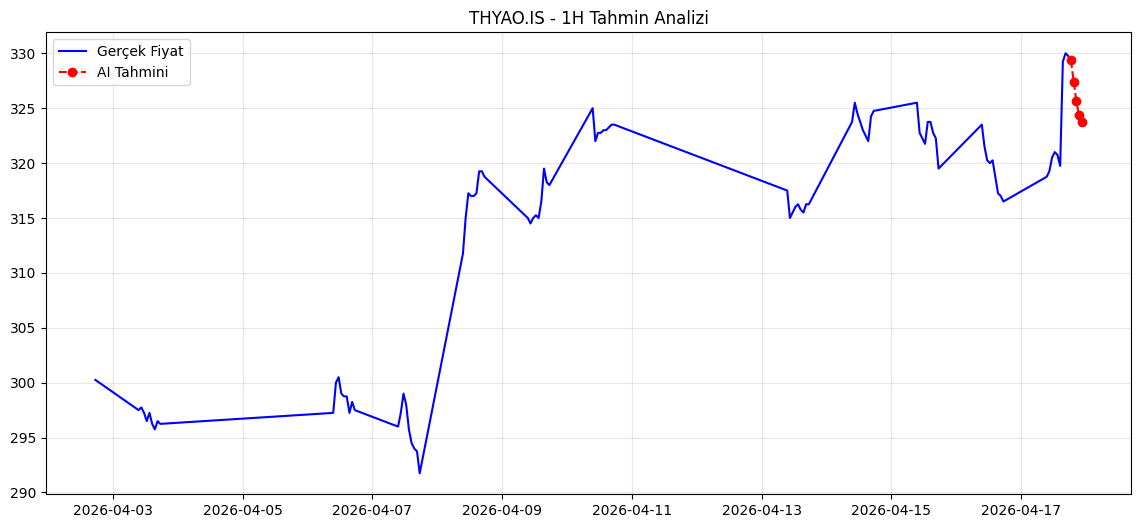

                Tarih  Tahmin Edilen Fiyat
0 2026-04-17 18:30:00               329.37
1 2026-04-17 19:30:00               327.43
2 2026-04-17 20:30:00               325.62
3 2026-04-17 21:30:00               324.36
4 2026-04-17 22:30:00               323.70


In [8]:
plt.figure(figsize=(14, 6))
# Son 100 günü göster
plt.plot(df.index[-100:], df['Close'][-100:], label="Gerçek Fiyat", color='blue')

# Tahmin tarihleri oluşturma
td = df.index[-1] - df.index[-2]
f_dates = [df.index[-1] + (td * i) for i in range(1, 6)]

plt.plot(f_dates, f_prices, label="AI Tahmini", color='red', linestyle='--', marker='o')
plt.title(f"{SYMBOL} - {INTERVAL} Tahmin Analizi")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tahmin Tablosu
forecast_df = pd.DataFrame({"Tarih": f_dates, "Tahmin Edilen Fiyat": f_prices.round(2)})
print(forecast_df)